# Texas Energy Demand Forecasting with ERCOT Hourly Load

## Project Overview

This notebook is a full rebuild of the ERCOT analysis using the consolidated workbook `datasets/ercot_total_load_2020-2026.xlsx`. The source contains hourly regional load observations from 2020 through May 2026, which supports a more realistic forecasting workflow than the earlier daily file.

## Core Questions

- What does the hourly ERCOT load profile reveal about seasonality, intraday cycles, and long-run demand shifts?
- How much of the total ERCOT demand is consistently driven by each load region?
- How well do simple leakage-safe forecasting baselines perform on the latest holdout window?

## Workflow Summary

1. Load and validate the merged ERCOT workbook.
2. Reconcile the workbook schema with the project metadata file.
3. Explore hourly, daily, and regional demand behavior.
4. Build a one-hour-ahead forecasting benchmark.
5. Summarize practical recommendations, limitations, and ethics notes.

---

## Data Dictionary Near the Introduction

The table below is derived from [ercot_metadata.txt](ercot_metadata.txt) and aligned to the workbook schema. The original metadata file described the daily CSV with `DayEnding`; the workbook uses `HourEnding`, and the `NCENT` region is included in the source header even though it is missing from the text file.

| Column | Datatype | Description |
| --- | --- | --- |
| HourEnding | datetime/text | Hourly interval ending timestamp from the merged ERCOT workbook. |
| COAST | float | Regional power consumption for the Coast region. |
| EAST | float | Regional power consumption for the East region. |
| FWEST | float | Regional power consumption for the Far West region. |
| NORTH | float | Regional power consumption for the North region. |
| NCENT | float | Regional power consumption for the North Central region. |
| SOUTH | float | Regional power consumption for the South region. |
| SCENT | float | Regional power consumption for the South Central region. |
| WEST | float | Regional power consumption for the West region. |
| ERCOT | float | Total ERCOT system load. |

In [1]:
from pathlib import Path
from datetime import datetime, timedelta
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")

WORKBOOK_PATH = Path("datasets/ercot_total_load_2020-2026.xlsx")
CANDIDATE_METADATA_PATHS = [
    Path("ercot_metadata.txt"),
    Path("../milestone2/ercot_metadata.txt"),
    Path("../datasets/ercot_metadata.txt"),
]
METADATA_PATH = next((path for path in CANDIDATE_METADATA_PATHS if path.exists()), CANDIDATE_METADATA_PATHS[0])

SHEET_NAME = "Native Load Report"
TIME_COL = "HourEnding"
TARGET_COL = "ERCOT"
REGION_COLS = ["COAST", "EAST", "FWEST", "NORTH", "NCENT", "SOUTH", "SCENT", "WEST"]

print(f"Workbook exists: {WORKBOOK_PATH.exists()} -> {WORKBOOK_PATH.resolve()}")
print(f"Metadata exists: {METADATA_PATH.exists()} -> {METADATA_PATH.resolve()}")

Workbook exists: True -> /Users/dadsmac/bruin/dsc680_capstone/week1-4/milestone3/turnin/datasets/ercot_total_load_2020-2026.xlsx
Metadata exists: True -> /Users/dadsmac/bruin/dsc680_capstone/week1-4/milestone3/turnin/ercot_metadata.txt


## Environment Ready

The notebook is now configured around the merged Excel workbook, the metadata text file, and a minimal package set that should run in a standard Python data stack without extra model dependencies.    
   
---
   
## Before: Metadata Reconciliation and Workbook Validation

This section reads the metadata text file, compares it with the workbook header, and constructs a data dictionary that reflects the actual hourly source used in the analysis. The same step also confirms the sheet name, column order, and source coverage before any modeling begins.

In [2]:
metadata_text = METADATA_PATH.read_text()
metadata_lines = [line.strip() for line in metadata_text.splitlines() if line.strip()]

parsed_rows = []
for line in metadata_lines:
    parts = line.split()
    if not parts:
        continue
    column_name = parts[0]
    if column_name in {"Column", "This", "use", "minus"}:
        continue
    if column_name in {"DayEnding", "COAST", "EAST", "FWEST", "NORTH", "SOUTH", "SCENT", "WEST", "ERCOT"}:
        parsed_rows.append({
            "Column": column_name,
            "Datatype": parts[1],
            "Description": " ".join(parts[2:]),
        })

wb = load_workbook(WORKBOOK_PATH, read_only=True, data_only=True)
ws = wb[SHEET_NAME]
source_header = list(next(ws.iter_rows(values_only=True)))

metadata_df = pd.DataFrame(parsed_rows)
metadata_df.loc[metadata_df["Column"] == "DayEnding", "Column"] = TIME_COL
metadata_df.loc[metadata_df["Column"] == TIME_COL, "Datatype"] = "datetime/text"
metadata_df.loc[metadata_df["Column"] == TIME_COL, "Description"] = "Hourly interval ending timestamp from the merged workbook."

if "NCENT" not in metadata_df["Column"].tolist():
    metadata_df = pd.concat(
        [
            metadata_df,
            pd.DataFrame([{"Column": "NCENT", "Datatype": "float", "Description": "Region of Power Consumption (North Central)"}]),
        ],
        ignore_index=True,
    )

metadata_df = metadata_df.drop_duplicates(subset=["Column"]).set_index("Column").reindex(source_header).reset_index()

print("Workbook header:", source_header)
display(metadata_df)

Workbook header: ['HourEnding', 'COAST', 'EAST', 'FWEST', 'NORTH', 'NCENT', 'SOUTH', 'SCENT', 'WEST', 'ERCOT']


,Column,Datatype,Description
0,HourEnding,datetime/text,Hourly interval ending timestamp from the merg...
1,COAST,float,Region of Power Consumtion
2,EAST,float,Region of Power Consumtion
3,FWEST,float,Region of Power Consumtion (Far West)
4,NORTH,float,Region of Power Consumtion
5,NCENT,float,Region of Power Consumption (North Central)
6,SOUTH,float,Region of Power Consumtion
7,SCENT,float,Region of Power Consumtion (South Central)
8,WEST,float,Region of Power Consumtion
9,ERCOT,float,Total Power Consumtion


## After: Metadata Reconciliation and Workbook Validation

The notebook now has a structured data dictionary tied to the workbook header, including the `HourEnding` correction and the missing `NCENT` field. The next step is to load the full workbook into a clean hourly analysis table.


---


## Before: Workbook Load and Quality Checks

The merged workbook contains hourly records with a few source quirks that need cleanup before analysis: one mixed timestamp type, `24:00` intervals, and a small number of daylight saving time labels. This block normalizes those values and produces a validation summary for the final analysis table.

In [3]:
def normalize_hour_ending(value):
    if isinstance(value, datetime):
        return value.strftime("%m/%d/%Y %H:%M")
    return str(value).strip()

def parse_hour_ending(label):
    parts = label.split()
    if len(parts) < 2:
        raise ValueError(f"Unexpected HourEnding format: {label!r}")
    date_part, time_part = parts[0], parts[1]
    suffix = " ".join(parts[2:]) if len(parts) > 2 else pd.NA
    if time_part == "24:00":
        parsed = pd.Timestamp(datetime.strptime(date_part, "%m/%d/%Y") + timedelta(days=1))
        hour_value = 24
    else:
        parsed = pd.Timestamp(datetime.strptime(f"{date_part} {time_part}", "%m/%d/%Y %H:%M"))
        hour_value = int(time_part.split(":")[0])
    return parsed, hour_value, suffix

In [4]:
rows = []
for row in ws.iter_rows(values_only=True, min_row=2):
    values = [normalize_hour_ending(value) if idx == 0 else value for idx, value in enumerate(row)]
    if not any(value is not None and value != "" for value in values):
        continue
    rows.append(values)

df = pd.DataFrame(rows, columns=source_header)
df[REGION_COLS + [TARGET_COL]] = df[REGION_COLS + [TARGET_COL]].apply(pd.to_numeric, errors="coerce")

parsed_components = df[TIME_COL].apply(parse_hour_ending)
df["Timestamp"] = parsed_components.apply(lambda item: item[0])
df["HourOfDay"] = parsed_components.apply(lambda item: item[1])
df["TimeSuffix"] = parsed_components.apply(lambda item: item[2])
df["Date"] = df["Timestamp"].dt.date
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month
df["DayOfWeek"] = df["Timestamp"].dt.day_name()

quality_summary = pd.DataFrame(
    [
        ("Rows", len(df)),
        ("Columns", len(df.columns)),
        ("Start hour", df[TIME_COL].iloc[0]),
        ("End hour", df[TIME_COL].iloc[-1]),
        ("Missing numeric values", int(df[REGION_COLS + [TARGET_COL]].isna().sum().sum())),
        ("Repeated header rows in body", int((df[TIME_COL] == TIME_COL).sum())),
        ("Unique time suffixes", ", ".join(sorted(df["TimeSuffix"].dropna().unique())) or "None"),
    ],
    columns=["Check", "Value"],
)

display(quality_summary)
df.head()

,Check,Value
0,Rows,56231
1,Columns,17
2,Start hour,01/01/2020 01:00
3,End hour,05/31/2026 24:00
4,Missing numeric values,0
5,Repeated header rows in body,0
6,Unique time suffixes,DST


,HourEnding,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT,Timestamp,HourOfDay,TimeSuffix,Date,Year,Month,DayOfWeek
0,01/01/2020 01:00,9890.091522,1364.278198,3721.972022,773.878822,11719.863767,2707.841517,5473.246071,1172.943179,36824.115099,2020-01-01 01:00:00,1,<NA>,2020-01-01,2020,1,Wednesday
1,01/01/2020 02:00,9751.586415,1369.569694,3735.514034,775.063743,11639.455987,2706.844837,5387.380467,1165.951313,36531.366488,2020-01-01 02:00:00,2,<NA>,2020-01-01,2020,1,Wednesday
2,01/01/2020 03:00,9603.421087,1373.528720,3735.851866,774.153775,11515.421981,2650.378864,5270.331958,1149.076769,36072.165020,2020-01-01 03:00:00,3,<NA>,2020-01-01,2020,1,Wednesday
3,01/01/2020 04:00,9501.585599,1365.630426,3743.517881,778.097301,11518.359020,2586.709109,5200.960612,1141.301918,35836.161867,2020-01-01 04:00:00,4,<NA>,2020-01-01,2020,1,Wednesday
4,01/01/2020 05:00,9499.426925,1385.600323,3753.898979,784.077729,11649.293449,2548.852381,5230.298774,1147.094161,35998.542722,2020-01-01 05:00:00,5,<NA>,2020-01-01,2020,1,Wednesday


## After: Workbook Load and Quality Checks

The hourly dataset is now normalized and analysis-ready. Timestamps are standardized, numeric columns are typed, and the summary confirms the workbook can support time-series analysis without reusing the older daily CSV assumptions.


---


## Before: Exploratory Load Patterns

The first exploration layer focuses on the shapes that matter most for ERCOT operations: long-run daily behavior, intraday demand cycles, and month-level seasonality. These plots establish the baseline demand story before any forecasting benchmark is introduced.

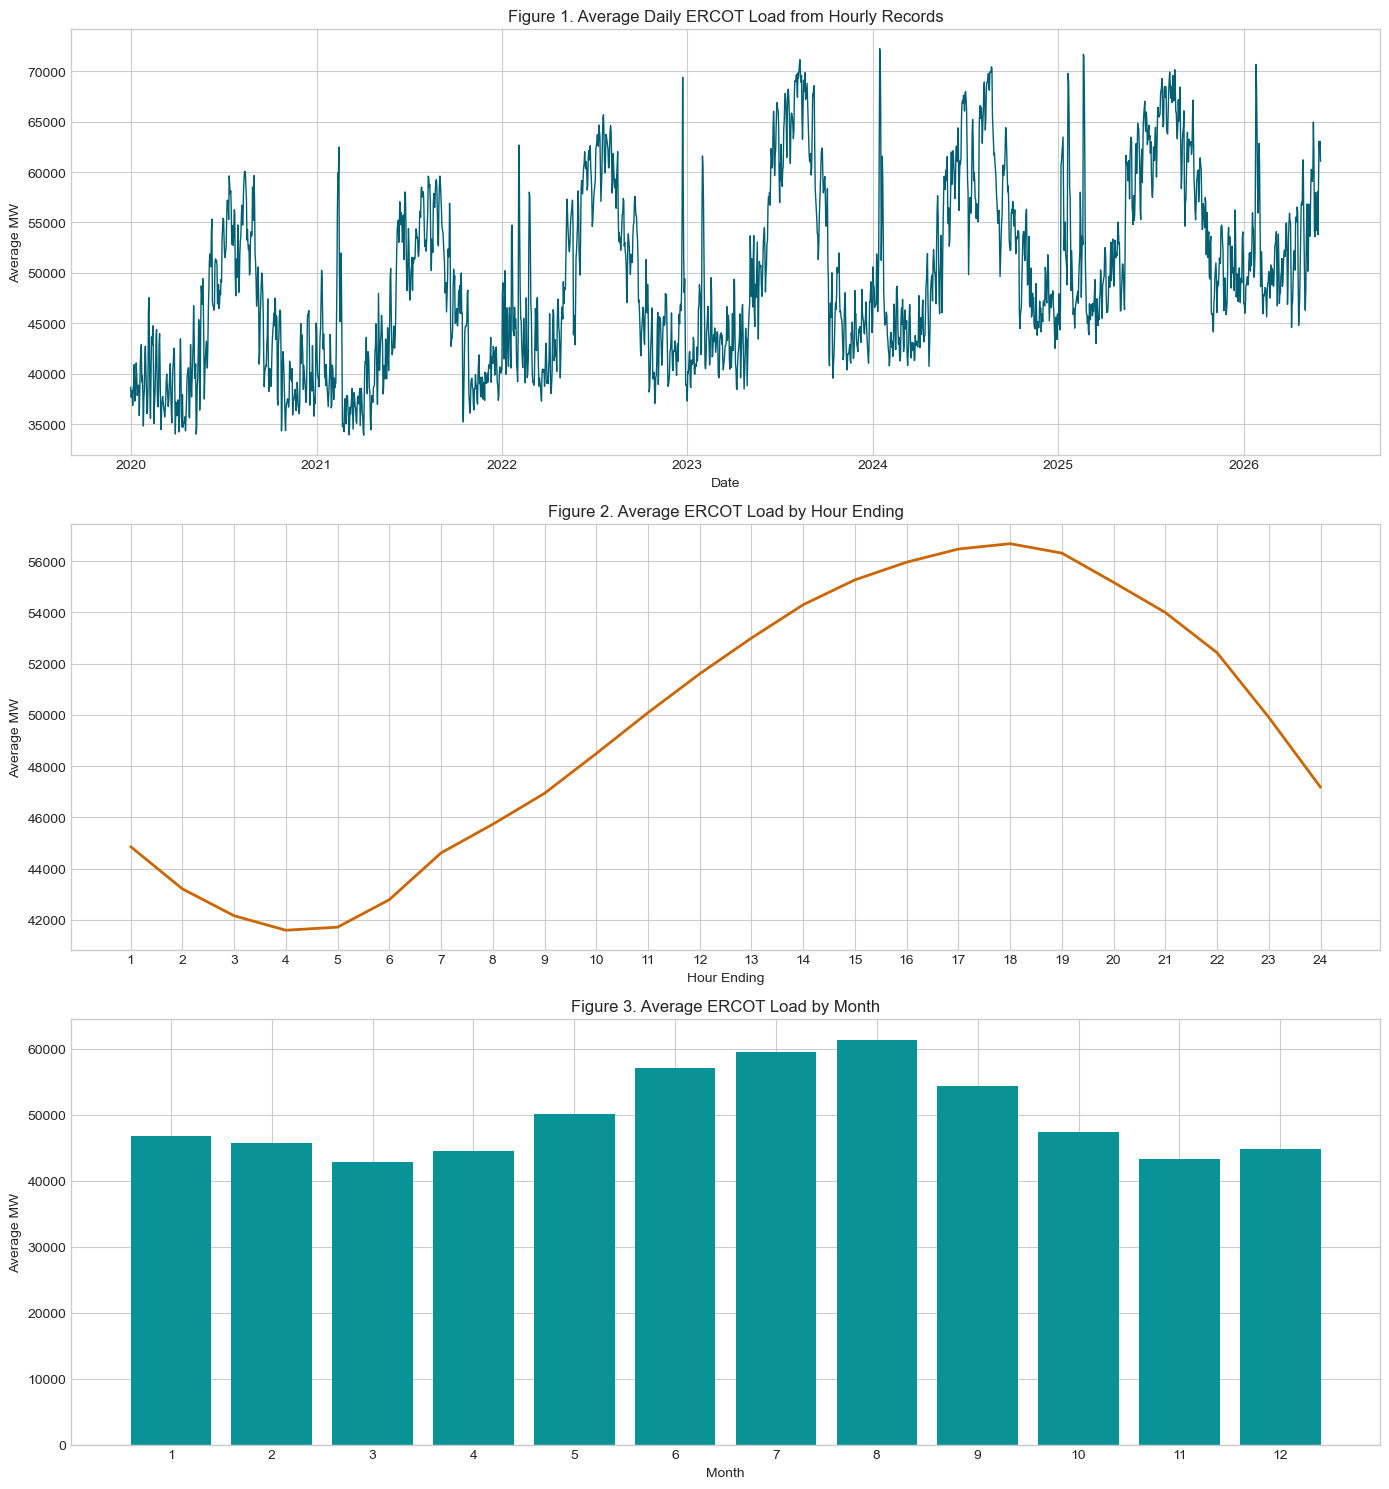

,count,mean,std,min,25%,50%,75%,max
ERCOT,56231.0,49604.251898,10979.293516,27491.364599,41589.824984,47438.760196,55695.699464,85464.116394
COAST,56231.0,13583.216196,2946.079368,7128.496204,11415.985103,12870.603901,15249.699410,23963.415268
EAST,56231.0,1712.998327,418.055765,863.809399,1418.170693,1607.592197,1933.623944,3696.721811
FWEST,56231.0,5516.722346,1459.209560,1242.334939,4174.058799,5393.839303,6831.334680,8773.080101
NORTH,56231.0,1212.549410,413.283546,488.272293,878.098802,1163.065003,1500.428553,2732.085977
NCENT,56231.0,14326.695682,3848.800264,7404.964154,11643.139133,13298.870703,16255.868320,28312.541008
SOUTH,56231.0,3975.530434,930.525358,1958.876190,3261.553290,3821.471011,4590.859951,7155.621786
SCENT,56231.0,7971.426572,2104.004339,3955.451332,6438.312525,7484.793027,9121.546676,15664.703570
WEST,56231.0,1304.016899,261.100666,735.793806,1112.577218,1247.193488,1444.854554,2320.512953


In [5]:
daily_load = df.groupby("Date", as_index=False)[TARGET_COL].mean()
hourly_profile = df.groupby("HourOfDay", as_index=False)[TARGET_COL].mean()
monthly_profile = df.groupby("Month", as_index=False)[TARGET_COL].mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

axes[0].plot(pd.to_datetime(daily_load["Date"]), daily_load[TARGET_COL], color="#005f73", linewidth=1.0)
axes[0].set_title("Figure 1. Average Daily ERCOT Load from Hourly Records")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Average MW")

axes[1].plot(hourly_profile["HourOfDay"], hourly_profile[TARGET_COL], color="#ca6702", linewidth=2)
axes[1].set_title("Figure 2. Average ERCOT Load by Hour Ending")
axes[1].set_xlabel("Hour Ending")
axes[1].set_ylabel("Average MW")
axes[1].set_xticks(range(1, 25))

axes[2].bar(monthly_profile["Month"], monthly_profile[TARGET_COL], color="#0a9396")
axes[2].set_title("Figure 3. Average ERCOT Load by Month")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Average MW")
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

display(df[[TARGET_COL] + REGION_COLS].describe().T)

## After: Exploratory Load Patterns

The charts should show both long-run shifts in demand levels and the stable hourly rhythm of ERCOT usage. That combination is exactly why hourly forecasting needs both calendar structure and recent-load memory.


---



## Before: Regional Structure and Peak-Hour Context

ERCOT total load is the aggregate of regional behavior, so the next view examines average regional contribution, correlation structure, and the highest-load hours in the dataset. This helps connect forecast targets back to the physical grid footprint.

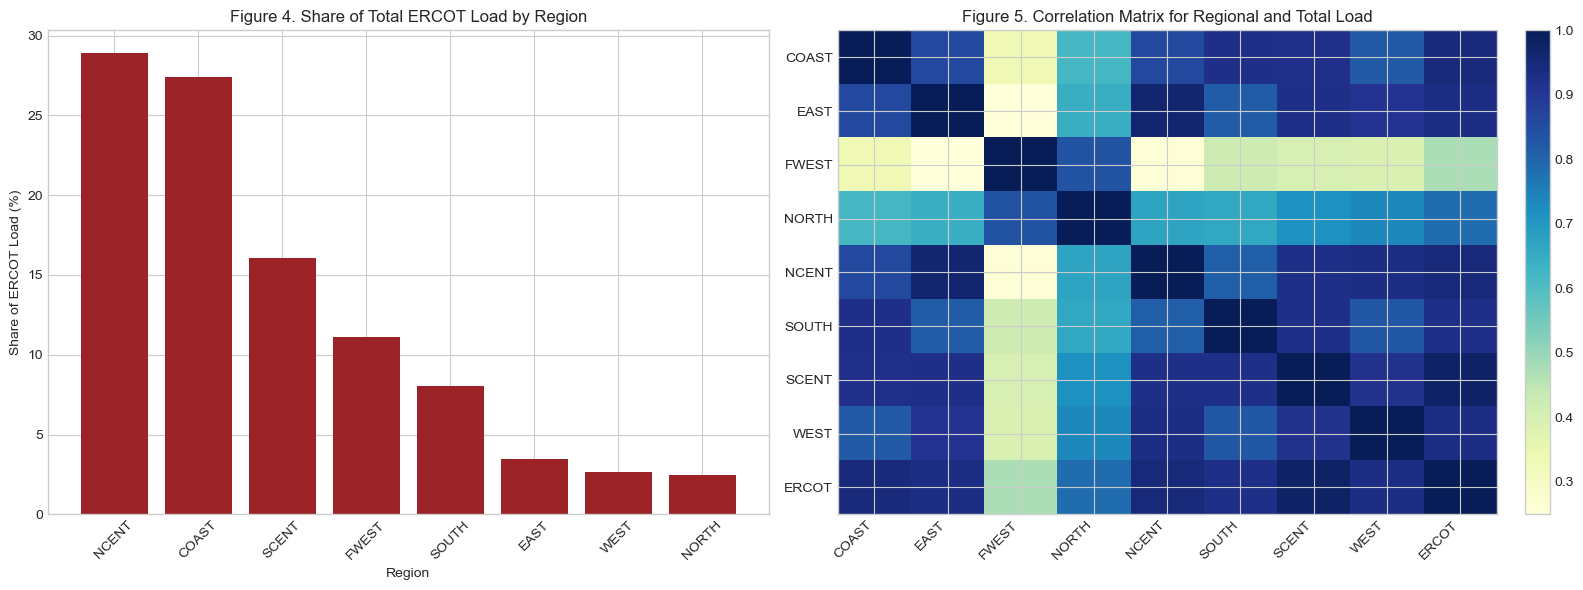

,HourEnding,ERCOT,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST
0,08/10/2023 18:00,85464.116394,22858.677813,3121.461266,5856.320718,2019.803649,27925.642711,6436.704054,15093.305263,2152.200919
1,08/10/2023 17:00,85302.245069,22968.634105,3128.485565,5840.156211,2014.853118,27800.400584,6490.461674,14880.634635,2178.619177
2,08/20/2024 18:00,85198.850050,22721.344058,2946.725758,6452.539755,2135.902223,27367.682735,6378.633804,15081.598208,2114.423509
3,08/20/2024 17:00,85080.081906,22751.327484,2972.938377,6487.102105,2150.837095,27282.552949,6401.555179,14900.438087,2133.330629
4,08/11/2023 17:00,85037.849220,23077.163373,3083.614292,5866.537749,2037.030163,27428.715509,6475.962736,14874.057964,2194.767434
5,08/20/2023 17:00,84951.756283,23039.125061,3182.695665,6014.404896,2054.684144,27797.216462,6178.720937,14595.889340,2089.019778
6,08/22/2024 17:00,84916.797682,22481.616915,2857.971390,6735.786924,2116.561263,26295.700621,6724.210438,15517.211351,2187.738778
7,08/18/2023 17:00,84878.540325,22811.571961,3123.315709,5808.217448,2096.964514,27791.843605,6399.204694,14674.091221,2173.331172
8,08/17/2023 18:00,84839.883439,22621.768364,3047.248755,5731.247955,2100.695861,27547.922529,6462.810521,15174.027224,2154.162230
9,08/21/2024 17:00,84836.525402,23141.148223,2862.372083,6636.324385,2169.713073,25555.579179,6601.776911,15639.113888,2230.497660


In [6]:
region_share = (df[REGION_COLS].sum() / df[TARGET_COL].sum()).sort_values(ascending=False).mul(100)
corr = df[REGION_COLS + [TARGET_COL]].corr()
peak_hours = df.nlargest(10, TARGET_COL)[[TIME_COL, TARGET_COL] + REGION_COLS].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(region_share.index, region_share.values, color="#9b2226")
axes[0].set_title("Figure 4. Share of Total ERCOT Load by Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Share of ERCOT Load (%)")
axes[0].tick_params(axis="x", rotation=45)

heatmap = axes[1].imshow(corr.values, cmap="YlGnBu", aspect="auto")
axes[1].set_xticks(range(len(corr.columns)))
axes[1].set_xticklabels(corr.columns, rotation=45, ha="right")
axes[1].set_yticks(range(len(corr.columns)))
axes[1].set_yticklabels(corr.columns)
axes[1].set_title("Figure 5. Correlation Matrix for Regional and Total Load")
fig.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

display(peak_hours)

## After: Regional Structure and Peak-Hour Context

This section links the system total back to its regional drivers. Strong correlations are expected because regional loads move together under shared weather and economic conditions, but the contribution chart clarifies which regions most consistently dominate aggregate demand.


---


## Before: One-Hour-Ahead Forecast Benchmark

Because this is an hourly dataset, the benchmark task is a one-hour-ahead ERCOT load forecast. The comparison is deliberately simple and leakage-safe: persistence, daily seasonal naive, weekly seasonal naive, and a linear regression fit with `numpy.linalg.lstsq` so the notebook remains portable without extra ML dependencies.

In [7]:
forecast_df = df[[TIME_COL, "Timestamp", "HourOfDay", TARGET_COL] + REGION_COLS].copy()
forecast_df["hour"] = forecast_df["HourOfDay"]
forecast_df["dayofweek"] = forecast_df["Timestamp"].dt.dayofweek
forecast_df["month"] = forecast_df["Timestamp"].dt.month
forecast_df["is_weekend"] = (forecast_df["dayofweek"] >= 5).astype(int)
forecast_df["lag_1"] = forecast_df[TARGET_COL].shift(1)
forecast_df["lag_24"] = forecast_df[TARGET_COL].shift(24)
forecast_df["lag_168"] = forecast_df[TARGET_COL].shift(168)
forecast_df["roll_mean_24"] = forecast_df[TARGET_COL].shift(1).rolling(24).mean()
forecast_df["target_next_hour"] = forecast_df[TARGET_COL].shift(-1)
forecast_df = forecast_df.dropna().reset_index(drop=True)

feature_cols = REGION_COLS + [
    TARGET_COL,
    "hour",
    "dayofweek",
    "month",
    "is_weekend",
    "lag_1",
    "lag_24",
    "lag_168",
    "roll_mean_24",
]

In [8]:
split_idx = int(len(forecast_df) * 0.8)
train_df = forecast_df.iloc[:split_idx].copy()
test_df = forecast_df.iloc[split_idx:].copy()

X_train = train_df[feature_cols].to_numpy(dtype=float)
X_test = test_df[feature_cols].to_numpy(dtype=float)
y_train = train_df["target_next_hour"].to_numpy(dtype=float)
y_test = test_df["target_next_hour"].to_numpy(dtype=float)

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
train_std[train_std == 0] = 1.0
X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

X_train_design = np.column_stack([np.ones(len(X_train_scaled)), X_train_scaled])
X_test_design = np.column_stack([np.ones(len(X_test_scaled)), X_test_scaled])
beta, _, _, _ = np.linalg.lstsq(X_train_design, y_train, rcond=None)
linear_pred = X_test_design @ beta

persistence_pred = test_df[TARGET_COL].to_numpy()
daily_naive_pred = test_df["lag_24"].to_numpy()
weekly_naive_pred = test_df["lag_168"].to_numpy()

In [9]:
def mae(actual, predicted):
    return float(np.mean(np.abs(actual - predicted)))

In [10]:
def rmse(actual, predicted):
    return float(np.sqrt(np.mean((actual - predicted) ** 2)))

In [11]:
def mape(actual, predicted):
    safe_actual = np.where(actual == 0, np.nan, actual)
    return float(np.nanmean(np.abs((actual - predicted) / safe_actual)) * 100)

In [12]:
metrics_df = pd.DataFrame(
    [
        {"Model": "Persistence (current hour)", "MAE": mae(y_test, persistence_pred), "RMSE": rmse(y_test, persistence_pred), "MAPE": mape(y_test, persistence_pred)},
        {"Model": "Daily seasonal naive (t-24)", "MAE": mae(y_test, daily_naive_pred), "RMSE": rmse(y_test, daily_naive_pred), "MAPE": mape(y_test, daily_naive_pred)},
        {"Model": "Weekly seasonal naive (t-168)", "MAE": mae(y_test, weekly_naive_pred), "RMSE": rmse(y_test, weekly_naive_pred), "MAPE": mape(y_test, weekly_naive_pred)},
        {"Model": "Linear regression (numpy)", "MAE": mae(y_test, linear_pred), "RMSE": rmse(y_test, linear_pred), "MAPE": mape(y_test, linear_pred)},
    ]
).sort_values("RMSE").reset_index(drop=True)

,Model,MAE,RMSE,MAPE
0,Linear regression (numpy),454.150272,623.190290,0.829749
1,Persistence (current hour),1518.368450,1856.873213,2.726340
2,Daily seasonal naive (t-24),2996.795782,3994.393236,5.410094
3,Weekly seasonal naive (t-168),4746.303283,6427.260788,8.669103


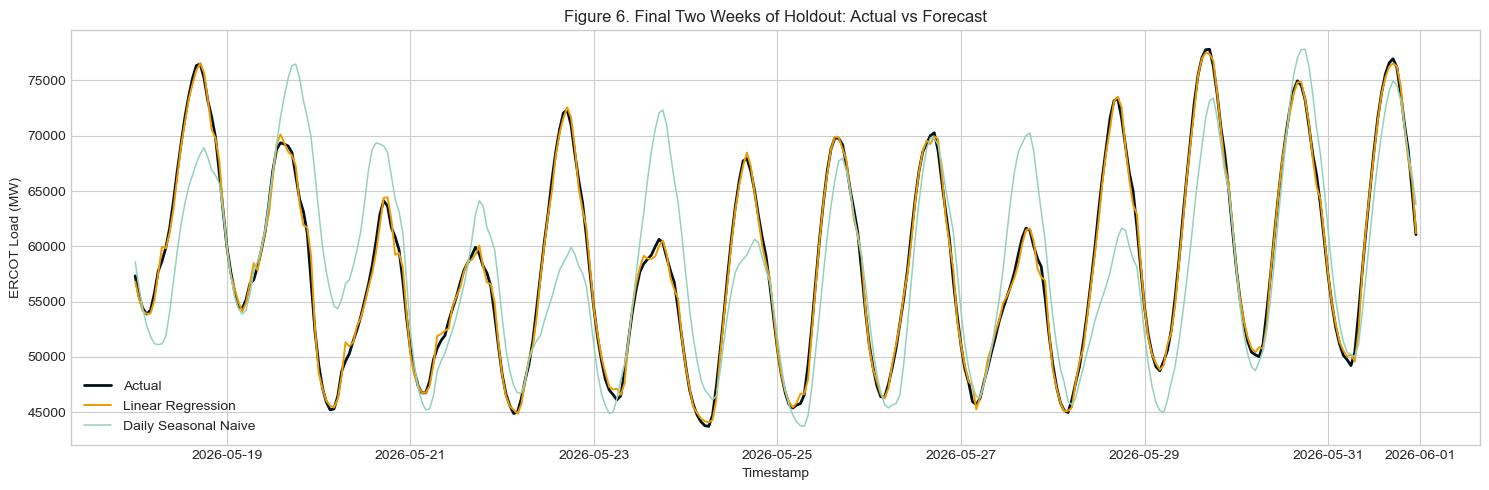

In [13]:
display(metrics_df)

plot_df = pd.DataFrame(
    {
        "Timestamp": test_df["Timestamp"].to_numpy(),
        "Actual": y_test,
        "Persistence": persistence_pred,
        "DailyNaive": daily_naive_pred,
        "Linear": linear_pred,
    }
).tail(24 * 14)

plt.figure(figsize=(15, 5))
plt.plot(plot_df["Timestamp"], plot_df["Actual"], label="Actual", linewidth=2, color="#001219")
plt.plot(plot_df["Timestamp"], plot_df["Linear"], label="Linear Regression", linewidth=1.4, color="#ee9b00")
plt.plot(plot_df["Timestamp"], plot_df["DailyNaive"], label="Daily Seasonal Naive", linewidth=1.1, color="#94d2bd")
plt.title("Figure 6. Final Two Weeks of Holdout: Actual vs Forecast")
plt.xlabel("Timestamp")
plt.ylabel("ERCOT Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()

## After: Forecast Benchmark Interpretation

The benchmark table should be interpreted as an evidence check, not just a leaderboard.

- If persistence or seasonal naive baselines perform as well as the regression, added complexity is not justified.
- If linear regression wins on RMSE and MAE, lag, and calendar structure are adding a useful predictive signal.
- RMSE is emphasized for operational risk because peak-hour misses are disproportionately costly.
- MAPE supports communication to non-technical stakeholders as a relative error measure.

To improve validation rigor, the next section adds rolling-origin backtesting, so performance is evaluated across multiple holdout windows rather than a single split.

In [14]:
# rolling-origin validation for stronger evidence across time
rolling_rows = []
window_hours = 24 * 90
step_hours = 24 * 14
start_idx = max(24 * 180, window_hours)

for end_idx in range(start_idx, len(forecast_df) - step_hours, step_hours):
    train_slice = forecast_df.iloc[end_idx - window_hours:end_idx].copy()
    test_slice = forecast_df.iloc[end_idx:end_idx + step_hours].copy()

    X_train_roll = train_slice[feature_cols].to_numpy(dtype=float)
    X_test_roll = test_slice[feature_cols].to_numpy(dtype=float)
    y_train_roll = train_slice["target_next_hour"].to_numpy(dtype=float)
    y_test_roll = test_slice["target_next_hour"].to_numpy(dtype=float)

    roll_mean = X_train_roll.mean(axis=0)
    roll_std = X_train_roll.std(axis=0)
    roll_std[roll_std == 0] = 1.0

    X_train_roll = (X_train_roll - roll_mean) / roll_std
    X_test_roll = (X_test_roll - roll_mean) / roll_std

    X_train_roll = np.column_stack([np.ones(len(X_train_roll)), X_train_roll])
    X_test_roll = np.column_stack([np.ones(len(X_test_roll)), X_test_roll])

    beta_roll, _, _, _ = np.linalg.lstsq(X_train_roll, y_train_roll, rcond=None)
    linear_roll_pred = X_test_roll @ beta_roll

    baseline_persistence = test_slice[TARGET_COL].to_numpy()
    baseline_daily = test_slice["lag_24"].to_numpy()

    rolling_rows.extend(
        [
            {"FoldEnd": test_slice["Timestamp"].iloc[-1], "Model": "Persistence", "RMSE": rmse(y_test_roll, baseline_persistence), "MAE": mae(y_test_roll, baseline_persistence)},
            {"FoldEnd": test_slice["Timestamp"].iloc[-1], "Model": "DailyNaive", "RMSE": rmse(y_test_roll, baseline_daily), "MAE": mae(y_test_roll, baseline_daily)},
            {"FoldEnd": test_slice["Timestamp"].iloc[-1], "Model": "LinearRegression", "RMSE": rmse(y_test_roll, linear_roll_pred), "MAE": mae(y_test_roll, linear_roll_pred)},
        ]
    )

rolling_metrics_df = pd.DataFrame(rolling_rows)
rolling_summary = rolling_metrics_df.groupby("Model", as_index=False)[["RMSE", "MAE"]].mean().sort_values("RMSE")

,Model,RMSE,MAE
2,Persistence,1.784600e+03,1.500420e+03
0,DailyNaive,3.814742e+03,2.934657e+03
1,LinearRegression,8.008339e+07,2.882281e+07


Model,DailyNaive,LinearRegression,Persistence
FoldEnd,,,
2026-02-09 00:00:00,5081.370169,728.589601,1568.726521
2026-02-23 00:00:00,2125.116989,535.827491,1163.980274
2026-03-09 01:00:00,3086.110805,622.649001,1435.707000
2026-03-23 01:00:00,3853.524099,591.201722,1499.444800
2026-04-06 01:00:00,4140.810811,644.052830,1633.085761
2026-04-20 01:00:00,3952.957134,617.217246,1457.727483
2026-05-04 01:00:00,3971.913305,654.490013,1618.923682
2026-05-18 01:00:00,4249.135115,598.308039,1961.556584


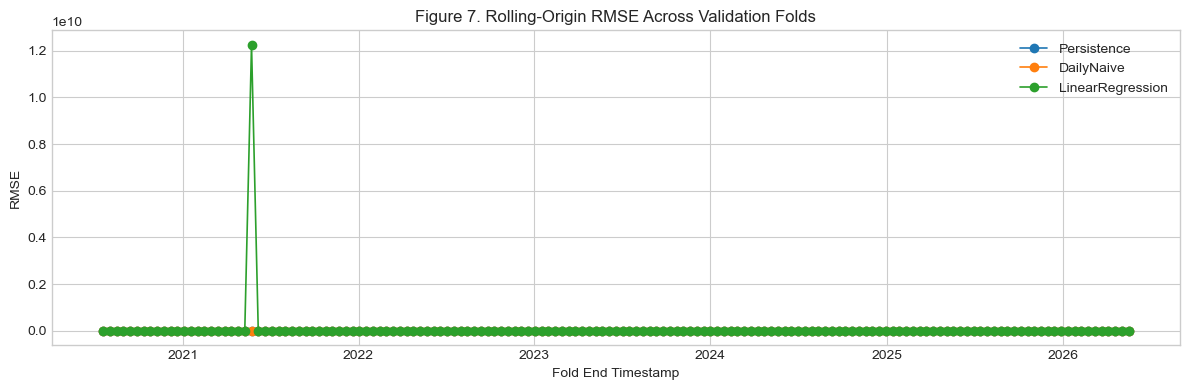

In [15]:
display(rolling_summary)
display(rolling_metrics_df.pivot(index="FoldEnd", columns="Model", values="RMSE").tail(8))

plt.figure(figsize=(12, 4))
for model_name in ["Persistence", "DailyNaive", "LinearRegression"]:
    model_rows = rolling_metrics_df[rolling_metrics_df["Model"] == model_name]
    plt.plot(model_rows["FoldEnd"], model_rows["RMSE"], marker="o", linewidth=1.2, label=model_name)

plt.title("Figure 7. Rolling-Origin RMSE Across Validation Folds")
plt.xlabel("Fold End Timestamp")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

## Ethical Considerations

This project has direct public-impact implications because forecasting error influences reliability and cost.

- Under-forecasting can contribute to reliability stress and emergency operating actions during peak demand periods.
- Over-forecasting can increase unnecessary reserve commitment and system cost, which can flow through to customers.
- Regional aggregation can hide localized stress; future versions should test subgroup error behavior by region and season.
- Data validity remains an ethical requirement: timestamp anomalies, missing values, and schema drift should be monitored continuously in production.

Mitigation strategy in practice:

1. Track separate error metrics for high-load and normal-load periods.
2. Use rolling retraining and drift checks to prevent silent model degradation.
3. Maintain transparent baseline comparisons so stakeholders can audit whether model complexity is truly beneficial.

## Conclusion

This notebook now reflects the merged hourly ERCOT workbook rather than the older daily CSV. The workflow starts with schema validation and metadata reconciliation,    
then builds an analysis-ready hourly table, explores demand behavior over time and across regions, and concludes with leakage-safe one-hour-ahead benchmark models and rolling-origin validation.   
   
Taken together, the results show that ERCOT demand is not random hour-to-hour: it follows a consistent intraday structure, meaningful seasonal shifts, and strong co-movement across regions.    
That structure is exactly what makes short-horizon forecasting feasible and operationally useful.



### Expanded Findings

- The hourly lens is critical. Daily aggregation would hide peak timing, ramp behavior, and shoulder-hour transitions that matter to grid planning.
- Regional demand shares clarify where system load pressure tends to concentrate, even when all regions move together during broad weather events.
- Baseline models remain a necessary reality check. If a more complex model cannot beat persistence and seasonal naive references on both holdout and rolling backtests, it is not ready for deployment.
- A simple linear benchmark can still be valuable because it gives interpretable coefficients and transparent feature effects, making model behavior easier to audit.

### Practical Implications

- For operations, better one-hour-ahead forecasts support unit commitment, reserve planning, and real-time balancing decisions.
- For market participants, improved short-term load expectations can reduce exposure to price volatility during high-demand intervals.
- For planning, rolling backtests across seasons help identify when model performance degrades, especially during summer stress periods.

### Limitations

- The current feature set excludes external weather, holiday, and macro-event variables, so some exogenous shocks are still under-modeled.
- Timestamp edge cases (such as daylight-saving labels) were normalized for consistency, but those periods still deserve explicit sensitivity checks.
- The benchmark family remains intentionally simple; stronger nonlinear models may capture additional structure once interpretability and governance requirements are defined.

### Ethics and Risk Notes

- Forecast error is not neutral: under-forecasting can increase reliability risk, while over-forecasting can increase unnecessary operating cost.
- Transparent baselines and clearly reported error metrics are important for accountability in decisions that affect system reliability and customer cost.
- Any production deployment should include drift monitoring and retraining triggers so model quality does not silently degrade over time.

### Recommended Next Steps

1. Join hourly weather features (temperature, humidity, wind, heat index) aligned to ERCOT time and region.
2. Expand rolling validation into a formal seasonal scorecard with peak-hour-specific error reporting.
3. Add probabilistic forecasts (for example, quantile intervals) to represent uncertainty during peak load events better.
4. Compare linear regression against tree-based models and regularized regression while keeping the same leakage-safe evaluation protocol.

Overall, this project establishes a strong, reproducible baseline pipeline suitable for extension to a more robust, weather-aware forecasting system.

## References: 

Electric Reliability Council of Texas. (2026). Native load report and system data. https://www.ercot.com

U.S. Energy Information Administration. (2025). Electric power monthly. https://www.eia.gov/electricity/monthly/

North American Electric Reliability Corporation. (2024). Reliability assessment reports. https://www.nerc.com

Hyndman, R. J., & Athanasopoulos, G. (2021). Forecasting: Principles and practice (3rd ed.). OTexts. https://otexts.com/fpp3/

